Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

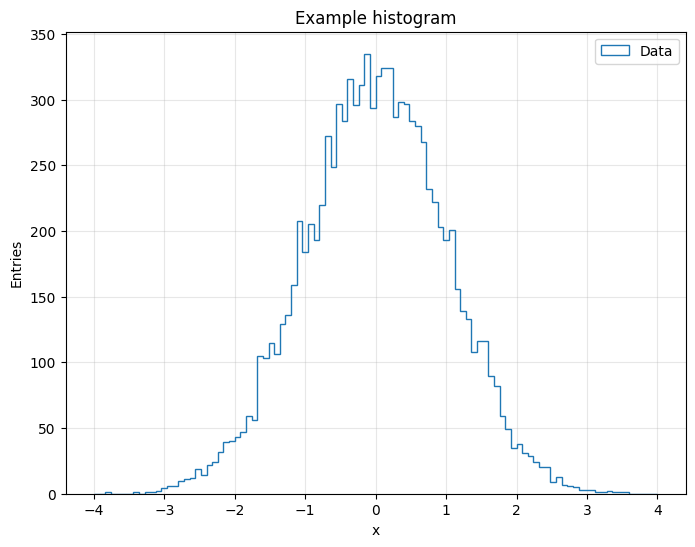

In [1]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generating random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Creating the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist( # "_" means we don't care about the third output of the function
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [2]:
!pip install uproot
# "!" allows to run shell command inside google colab instead of running it in termnial
# need to read/write ROOT files(.root), without actually intalling a complete ROOT package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 39.4 MB/s eta 0:00:00


In [3]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root
# creates directory LHCb_Data, then moves into it
# downloads file B2HHH_MagnetDown.root from CERN Open Data inside this folder
# This file contains data about B -> HHH  decays channels, here H is chared hadron, usually K or pion

--2026-02-24 22:19:23--  http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root
Resolving opendata.cern.ch (opendata.cern.ch)... 137.138.6.31, 2001:1458:201:8b::100:1c8
Connecting to opendata.cern.ch (opendata.cern.ch)|137.138.6.31|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 666484974 (636M) [application/octet-stream]
Saving to: ‘B2HHH_MagnetDown.root’

B2HHH_MagnetDown.ro 100%[===================>] 635.61M  36.2MB/s    in 18s     

2026-02-24 22:19:42 (34.6 MB/s) - ‘B2HHH_MagnetDown.root’ saved [666484974/666484974]



In [4]:
import uproot

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

px

array([  375.2842054 , -4985.13078543, -1265.45654435, ...,
        2606.91083928,  -294.71098895,   499.04234923])

In [5]:
len(px)

5135823

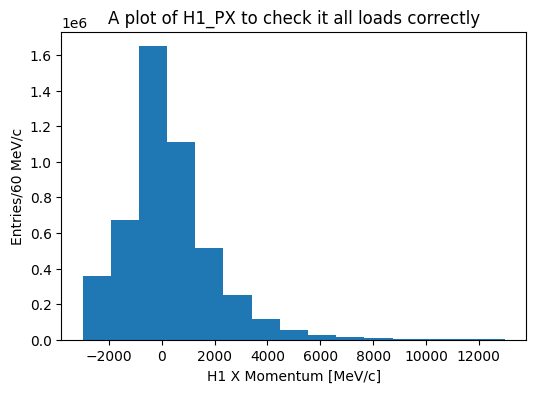

In [6]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(
    px,
    #bins=10,
    bins = 15,
    #range=(-3000, 150000),
    range = (-3000, 13000),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1330894601.py:44: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
/tmp/ipython-input-1330894601.py:44: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


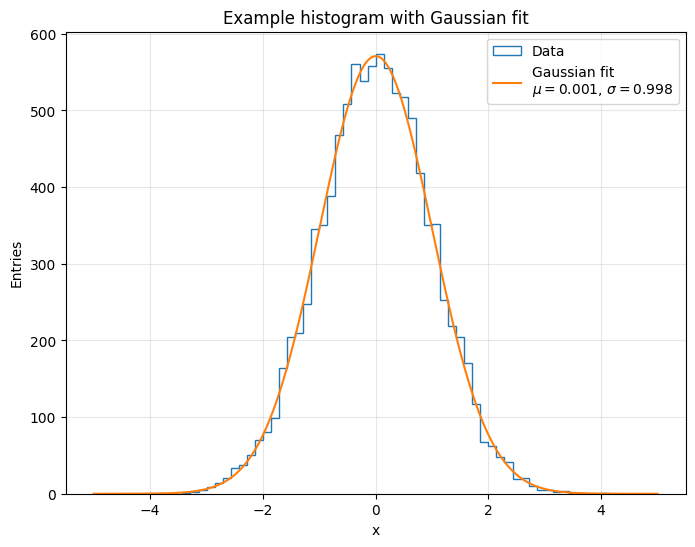

In [7]:
# Histogram settings
n_bins = 70
x_min, x_max = - 5, 5

# Creating the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Displaying the plot
plt.show()


## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [ ]:
#Using Uproot, load your data file and load the variables you think are useful for this analysis - I recommend learning what your data structure is...so plotting and calculations becomes easier later.


In [8]:
# Root Tree - table/dataframe
# branch - column
# entry - row
branches = tree.keys()
branches

['B_FlightDistance',
 'B_VertexChi2',
 'H1_PX',
 'H1_PY',
 'H1_PZ',
 'H1_ProbK',
 'H1_ProbPi',
 'H1_Charge',
 'H1_IPChi2',
 'H1_isMuon',
 'H2_PX',
 'H2_PY',
 'H2_PZ',
 'H2_ProbK',
 'H2_ProbPi',
 'H2_Charge',
 'H2_IPChi2',
 'H2_isMuon',
 'H3_PX',
 'H3_PY',
 'H3_PZ',
 'H3_ProbK',
 'H3_ProbPi',
 'H3_Charge',
 'H3_IPChi2',
 'H3_isMuon']

In [9]:
import awkward as ak
# specific library needed to handle jagged/ nested/ variable-legnth dat

vars_to_load = [
    "H1_PX","H1_PY","H1_PZ",
    "H2_PX","H2_PY","H2_PZ",
    "H3_PX","H3_PY","H3_PZ",
]

arr = tree.arrays(vars_to_load)   # awkward array table

def p_tot(px, py, pz): # returns absolute value of momentum for a given particle
    return np.sqrt(px*px + py*py + pz*pz)

H1_Ptot = p_tot(arr["H1_PX"], arr["H1_PY"], arr["H1_PZ"])
H2_Ptot = p_tot(arr["H2_PX"], arr["H2_PY"], arr["H2_PZ"])
H3_Ptot = p_tot(arr["H3_PX"], arr["H3_PY"], arr["H3_PZ"])




In [ ]:
#Here make a plot of the Total momentum of each of the three daughters on one plot

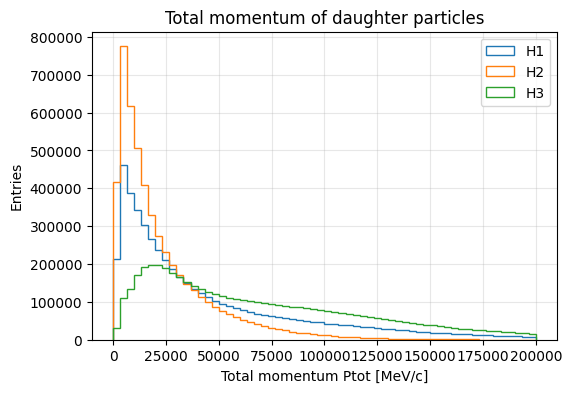

In [10]:
plt.figure(figsize=(6,4))

bins = 60
rng = (0, 200000)

plt.hist(ak.to_numpy(H1_Ptot), bins=bins, range=rng, histtype="step", label="H1")
plt.hist(ak.to_numpy(H2_Ptot), bins=bins, range=rng, histtype="step", label="H2")
plt.hist(ak.to_numpy(H3_Ptot), bins=bins, range=rng, histtype="step", label="H3")

plt.xlabel("Total momentum Ptot [MeV/c]")
plt.ylabel("Entries")
plt.title("Total momentum of daughter particles")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

In [ ]:
#use the histogram plotting tools, plot the momentum of the mother

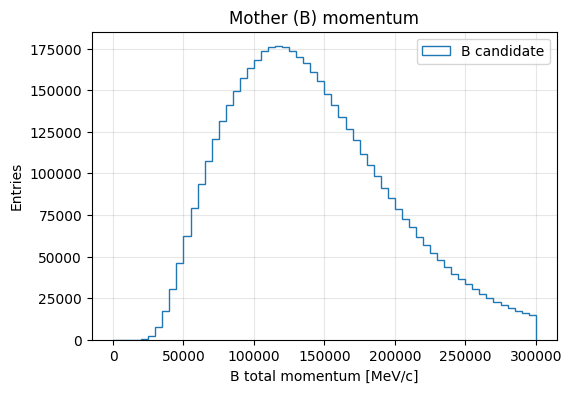

In [11]:
B_PX = arr["H1_PX"] + arr["H2_PX"] + arr["H3_PX"]
B_PY = arr["H1_PY"] + arr["H2_PY"] + arr["H3_PY"]
B_PZ = arr["H1_PZ"] + arr["H2_PZ"] + arr["H3_PZ"]

B_Ptot = p_tot(B_PX, B_PY, B_PZ) # momentum of the particle that will decay

plt.figure(figsize=(6,4))

plt.hist(
    ak.to_numpy(B_Ptot),
    bins=60,
    range=(0, 300000),
    histtype="step",
    label="B candidate"
)

plt.xlabel("B total momentum [MeV/c]")
plt.ylabel("Entries")
plt.title("Mother (B) momentum")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [ ]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.

In [12]:
entry = arr[45]
for field in arr.fields:
    print(f"{field:6s} : {round(entry[field], 4)}")

H1_PX  : 420.3414
H1_PY  : -110.6628
H1_PZ  : 5883.7664
H2_PX  : -985.6368
H2_PY  : 630.9894
H2_PZ  : 35342.1386
H3_PX  : -6242.3004
H3_PY  : -862.2131
H3_PZ  : 277275.4923


We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

In [ ]:
#First find the energy (you might have to do some physics thinking here)

# The using the total momentum find the reconstructed mass of the B

# Now write your new variables to an array

#Now plot a histogram of the range of masses of the B meson.

#Does this match what we would expect from theory?

#What are the features of your plot that you see?

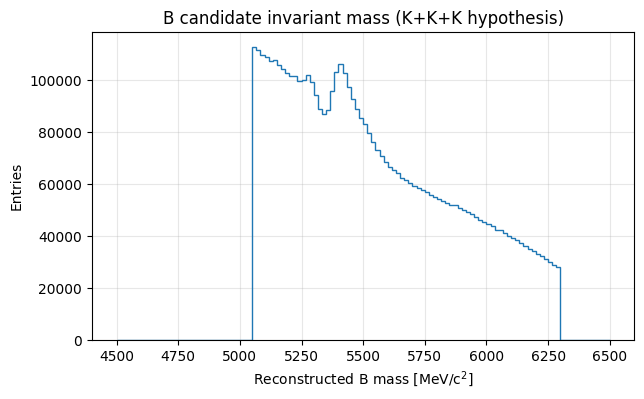

In [13]:
# Our hypothesis is that all 3 particles are Kaons with mass mK = 493.677 MeV/c^2
# If the result doesn't make any sense we will check 3 pions hypothesis or may be some other ones


mK = 493.677  # MeV/c^2

def energy(p, m):
    return np.sqrt(p*p + m*m)

H1_E = energy(H1_Ptot, mK)
H2_E = energy(H2_Ptot, mK)
H3_E = energy(H3_Ptot, mK)

# B energy
B_E = H1_E + H2_E + H3_E


# reconstructed invariant mass (guard tiny negative from rounding)
B_M2 = B_E*B_E - B_Ptot*B_Ptot
B_M  = np.sqrt(np.maximum(B_M2, 0))


# reorganize new variables into an array
new_arr = ak.zip({
    "H1P_tot": H1_Ptot, "H2_Ptot": H2_Ptot, "H3_Ptot": H3_Ptot,
    "H1_E": H1_E, "H2_E": H2_E, "H3_E": H3_E,
    "B_PX": B_PX, "B_PY": B_PY, "B_PZ": B_PZ,
    "B_Ptot":  B_Ptot,
    "B_E":  B_E,
    "B_M":  B_M
})



BM = ak.to_numpy(B_M)

plt.figure(figsize=(7,4))
plt.hist(BM, bins=120, range=(4500, 6500), histtype="step")
plt.xlabel("Reconstructed B mass [MeV/c$^2$]")
plt.ylabel("Entries")
plt.title("B candidate invariant mass (K+K+K hypothesis)")
plt.grid(alpha=0.3)
plt.show()



In [14]:
BM = ak.to_numpy(B_M)
print("min, max:", BM.min(), BM.max())
# this explains why we have walls from boths sides of the plot

min, max: 5050.000019908188 6299.999237730949


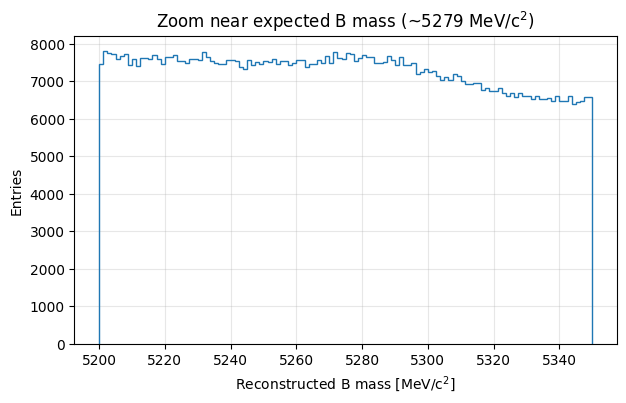

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(BM, bins=120, range=(5200, 5350), histtype="step")
plt.xlabel("Reconstructed B mass [MeV/c$^2$]")
plt.ylabel("Entries")
plt.title("Zoom near expected B mass (~5279 MeV/c$^2$)")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# At this point we do see a bump but about 100-200 Mev higher that we would love to
# The expected mass is ~5279 MeV/c^2
# This may be caused by the fact that some of the tracks came from
# other reactions, or may be the hypotheses about 3 Kaons was wrong,
# or may be we just have a statistical glitch in the data


We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

In [ ]:
#Make plots of H1/H2/H3 _ProbK on one plot


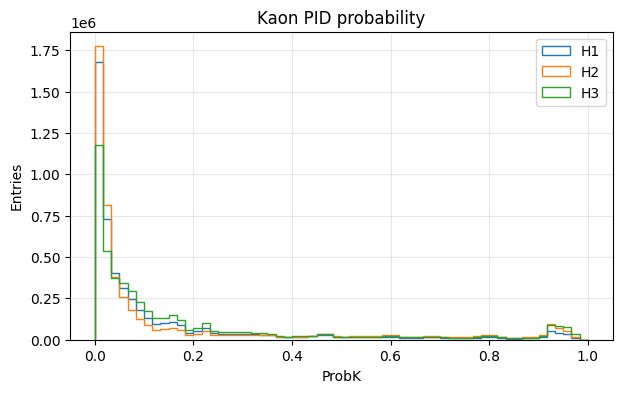

In [15]:
# Now we update the old versions of vars_to_load (momenta + ProbK)
# It is cleaner to do it this way than try to created vars_to_load that will
# contain everything for every future experiment

vars_to_load = [
    "H1_PX","H1_PY","H1_PZ","H1_ProbK",
    "H2_PX","H2_PY","H2_PZ","H2_ProbK",
    "H3_PX","H3_PY","H3_PZ","H3_ProbK",
]

arr = tree.arrays(vars_to_load)


H1_ProbK = ak.to_numpy(arr["H1_ProbK"]) # probability of H1 is a Kayon
H2_ProbK = ak.to_numpy(arr["H2_ProbK"])
H3_ProbK = ak.to_numpy(arr["H3_ProbK"])

plt.figure(figsize=(7,4))

plt.hist(H1_ProbK, bins=60, range=(0,1), histtype="step", label="H1")
plt.hist(H2_ProbK, bins=60, range=(0,1), histtype="step", label="H2")
plt.hist(H3_ProbK, bins=60, range=(0,1), histtype="step", label="H3")

plt.xlabel("ProbK")
plt.ylabel("Entries")
plt.title("Kaon PID probability") #Particle Identifier
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Huge spike near zero for all the Kaons - most of the particles
# created are unlikely to be Kaons

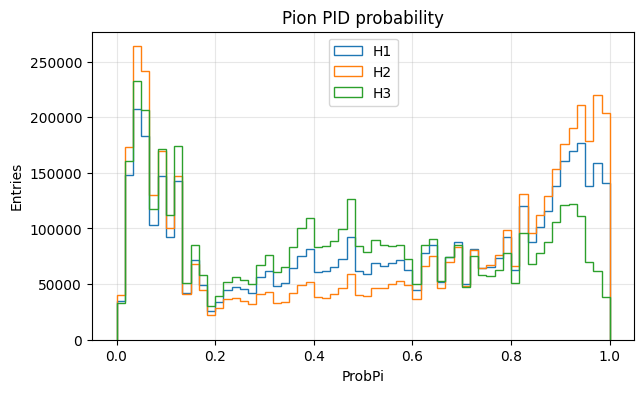

In [16]:
# Do the same for the Probability of being a Pion. Do these distributions match expectations?


# we update var_to_load by adding prob for Hi to be a pion
vars_to_load = [
    "H1_PX","H1_PY","H1_PZ","H1_ProbK","H1_ProbPi",
    "H2_PX","H2_PY","H2_PZ","H2_ProbK","H2_ProbPi",
    "H3_PX","H3_PY","H3_PZ","H3_ProbK","H3_ProbPi",
]

arr = tree.arrays(vars_to_load)

H1_ProbPi = ak.to_numpy(arr["H1_ProbPi"])
H2_ProbPi = ak.to_numpy(arr["H2_ProbPi"])
H3_ProbPi = ak.to_numpy(arr["H3_ProbPi"])


plt.figure(figsize=(7,4))

plt.hist(H1_ProbPi, bins=60, range=(0,1), histtype="step", label="H1")
plt.hist(H2_ProbPi, bins=60, range=(0,1), histtype="step", label="H2")
plt.hist(H3_ProbPi, bins=60, range=(0,1), histtype="step", label="H3")

plt.xlabel("ProbPi")
plt.ylabel("Entries")
plt.title("Pion PID probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [17]:
# Based on this plot we can say that we have a lot of points(due to bump near ProbPi ~ 1)
# At the same time not all the particles are poins since we also have a sizable bump near ProbPi ~ 0

for name, x in [("H1", H1_ProbPi), ("H2", H2_ProbPi), ("H3", H3_ProbPi)]:
    print(
        f"{name} "
        f"ProbPi>0.8: {(x > 0.8).mean():.3f} "
        f"ProbPi<0.2: {(x < 0.2).mean():.3f}"
    )


H1 ProbPi>0.8: 0.306 ProbPi<0.2: 0.243
H2 ProbPi>0.8: 0.364 ProbPi<0.2: 0.281
H3 ProbPi>0.8: 0.197 ProbPi<0.2: 0.279


In [ ]:
#For all our particles, make a plot of the B_VertexChi2

#Feeling ambitious? Maybe make a 2d plot of Kaon and Pion Prob in a 2 dimensional analysis?


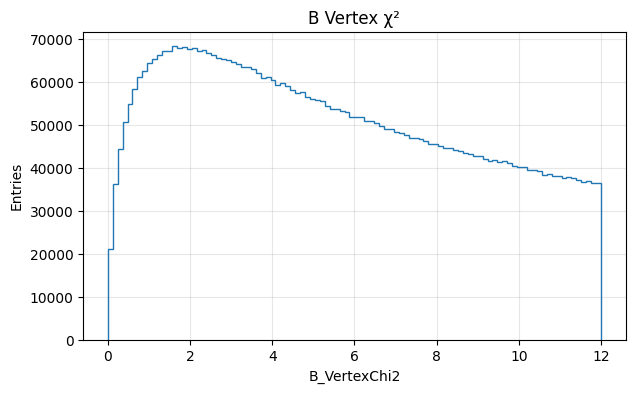

In [18]:
vars_to_load = ["B_VertexChi2"]
# this variable tells us quality of the reconstructed B-meson decay vertex
arr = tree.arrays(vars_to_load)

B_VertexChi2 = ak.to_numpy(arr["B_VertexChi2"])

plt.figure(figsize=(7,4))
plt.hist(B_VertexChi2, bins=100, histtype="step")
plt.xlabel("B_VertexChi2")
plt.ylabel("Entries")
plt.title("B Vertex χ²")
plt.grid(alpha=0.3)
plt.show()



In [ ]:
# Distribution peaks at low chi^2 (~1–2) ->
# most B candidates have good vertex fits
#(are concistent with coming from the the same decay point)
# Presense of a tail -> some background is present


/tmp/ipython-input-3699061047.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


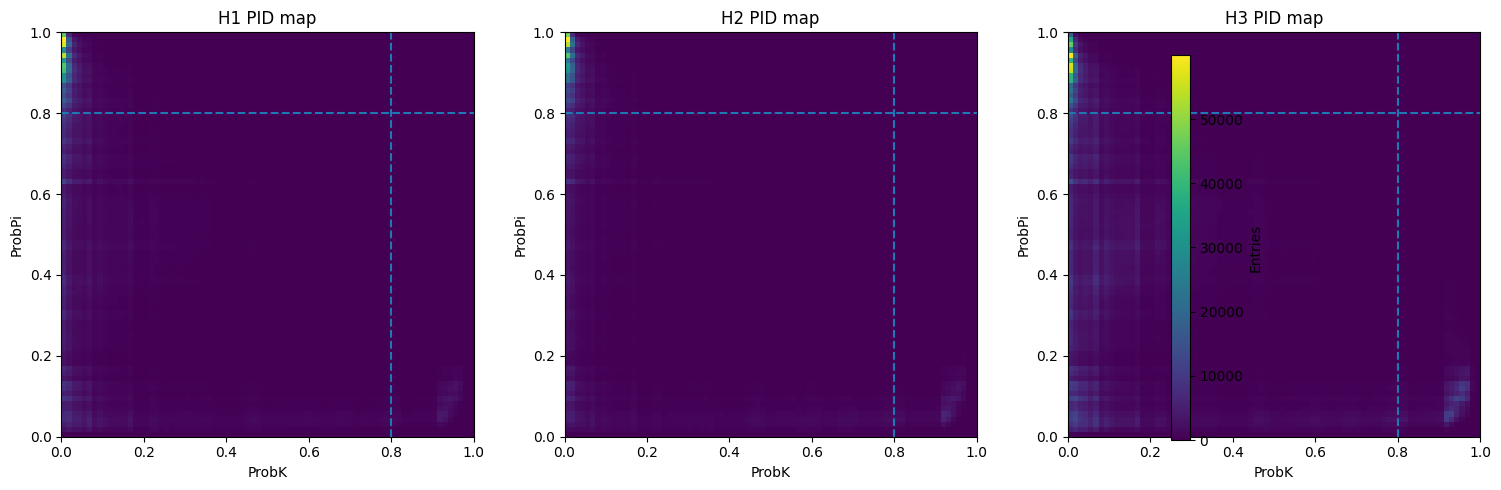

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

tracks = [
    ("H1", H1_ProbK, H1_ProbPi),
    ("H2", H2_ProbK, H2_ProbPi),
    ("H3", H3_ProbK, H3_ProbPi),
]

for ax, (name, probk, probpi) in zip(axes, tracks):
    h = ax.hist2d(
        probk,
        probpi,
        bins=80,
        range=[[0,1],[0,1]]
    )

    ax.set_xlabel("ProbK")
    ax.set_ylabel("ProbPi")
    ax.set_title(f"{name} PID map")

    # Optional cut guides
    ax.axvline(0.8, linestyle="--") # right of the vertical line are Kaons(we believe)
    ax.axhline(0.8, linestyle="--") # above the horizontal line are Poins(we believe)

fig.colorbar(h[3], ax=axes, label="Entries")

plt.tight_layout()
plt.show()


In [20]:
# Samplie is pi0n-dominated
# It also contains some kaons
for name, probk, probpi in [
    ("H1", H1_ProbK, H1_ProbPi),
    ("H2", H2_ProbK, H2_ProbPi),
    ("H3", H3_ProbK, H3_ProbPi),
]:
    pion_like  = probpi > 0.8
    kaon_like  = probk  > 0.8

    print(
        f"{name} "
        f"Pion-like: {pion_like.mean():.3f} "
        f"Kaon-like: {kaon_like.mean():.3f}"
    )


H1 Pion-like: 0.306 Kaon-like: 0.040
H2 Pion-like: 0.364 Kaon-like: 0.069
H3 Pion-like: 0.197 Kaon-like: 0.075


Using these plots, we can now make a preselection string. This is a text string that looks like

In [ ]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)
selection=("H1_ProbPi>0.9&H2_ProbPi>0.9&H3_ProbPi>0.9&!H1_isMuon&H2_isElectron&H3_isElephant")

In [21]:
selection = (
    # First we use constrains on probabilities:  we want Pions and
    # based on our previous experience we don't want Kaons as outcoming particles
    "(H1_ProbPi > 0.9) & (H2_ProbPi > 0.9) & (H3_ProbPi > 0.9) "
    "& (H1_ProbK < 0.2) & (H2_ProbK < 0.2) & (H3_ProbK < 0.2) "
    # It good to prohibit muions as products but the best we can do is to veto muons
    "& (H1_isMuon == 0) & (H2_isMuon == 0) & (H3_isMuon == 0) "
    # --- Track displacement: daughters should not point to PV ---
    "& (H1_IPChi2 > 9) & (H2_IPChi2 > 9) & (H3_IPChi2 > 9) "
    # --- B candidate should form a good displaced vertex ---
    "& (B_VertexChi2 < 10) & (B_FlightDistance > 3)"
)


In [ ]:
#Look at the total number of entries originally and the new number - how much of your data did you throw away? Was this a good idea? :(

In [22]:
# count BEFORE (no cut)
n_all = tree.num_entries

# count AFTER (our selection cut)
vars_min = ["H1_ProbPi","H2_ProbPi","H3_ProbPi","H1_isMuon","H2_isMuon","H3_isMuon"]
arr_cut = tree.arrays(vars_min, cut=selection)
n_sel = len(arr_cut)

thrown = n_all - n_sel
frac_thrown = thrown / n_all
frac_kept = n_sel / n_all

print(f"Original entries: {n_all}")
print(f"Selected entries: {n_sel}")
print(f"Thrown away: {thrown}  ({frac_thrown:.3f})")
print(f"Kept:              ({frac_kept:.3f})")


Original entries: 5135823
Selected entries: 5171
Thrown away: 5130652  (0.999)
Kept:              (0.001)


In [ ]:
# From one hand we have lost a lot of data
# From the other hand have greatly purified the data

In [ ]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?


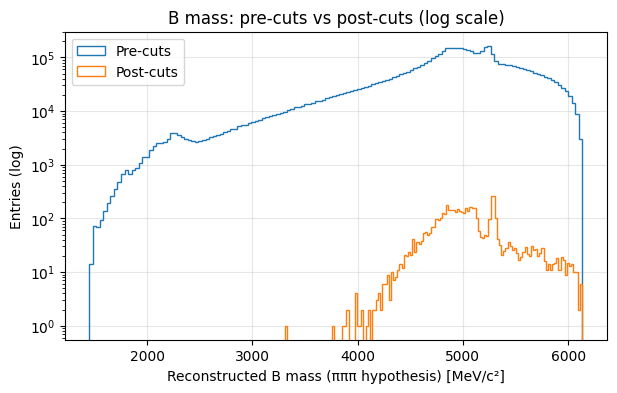

In [23]:
# --- load what we need (momenta + PID + muon flags) ---
vars_to_load = [
    "H1_PX","H1_PY","H1_PZ","H1_ProbPi","H1_isMuon",
    "H2_PX","H2_PY","H2_PZ","H2_ProbPi","H2_isMuon",
    "H3_PX","H3_PY","H3_PZ","H3_ProbPi","H3_isMuon",
]
arr_all = tree.arrays(vars_to_load)
arr_cut = tree.arrays(vars_to_load, cut=selection)

# assuming following  pion mass
m_pi = 139.57039  # MeV/c^2

def reco_B_mass(arr):
    px1, py1, pz1 = ak.to_numpy(arr["H1_PX"]), ak.to_numpy(arr["H1_PY"]), ak.to_numpy(arr["H1_PZ"])
    px2, py2, pz2 = ak.to_numpy(arr["H2_PX"]), ak.to_numpy(arr["H2_PY"]), ak.to_numpy(arr["H2_PZ"])
    px3, py3, pz3 = ak.to_numpy(arr["H3_PX"]), ak.to_numpy(arr["H3_PY"]), ak.to_numpy(arr["H3_PZ"])

    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    p3 = np.sqrt(px3*px3 + py3*py3 + pz3*pz3)

    E1 = np.sqrt(p1*p1 + m_pi*m_pi)
    E2 = np.sqrt(p2*p2 + m_pi*m_pi)
    E3 = np.sqrt(p3*p3 + m_pi*m_pi)

    PX = px1 + px2 + px3
    PY = py1 + py2 + py3
    PZ = pz1 + pz2 + pz3
    E  = E1 + E2 + E3

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    m2 = np.maximum(m2, 0)  # numerical safety
    return np.sqrt(m2)

m_pre  = reco_B_mass(arr_all)
m_post = reco_B_mass(arr_cut)

# --- overlay plot ---
plt.figure(figsize=(7,4))
plt.hist(m_pre,  bins=140, histtype="step", label="Pre-cuts")
plt.hist(m_post, bins=140, histtype="step", label="Post-cuts")
plt.yscale("log")
plt.xlabel("Reconstructed B mass (πππ hypothesis) [MeV/c²]")
plt.ylabel("Entries (log)")
plt.title("B mass: pre-cuts vs post-cuts (log scale)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [24]:
counts, edges = np.histogram(m_post, bins=200, range=(4800, 5800))
i = np.argmax(counts)
peak_center = 0.5 * (edges[i] + edges[i+1])

print(f"Post-cut peak ~ {peak_center:.1f} MeV/c^2")
print(f"Difference from 5280 MeV ~ {peak_center - 5280:.1f} MeV/c^2")


Post-cut peak ~ 5287.5 MeV/c^2
Difference from 5280 MeV ~ 7.5 MeV/c^2


In [ ]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!

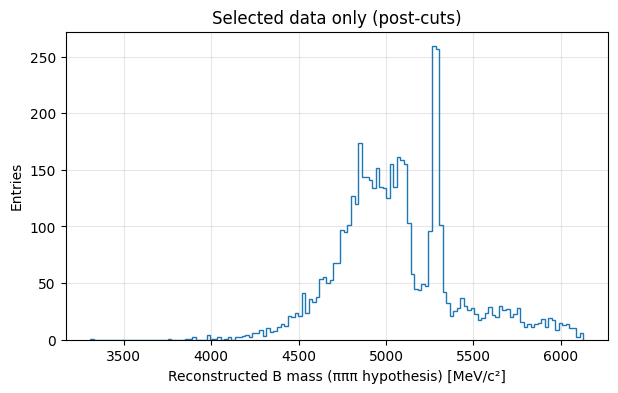

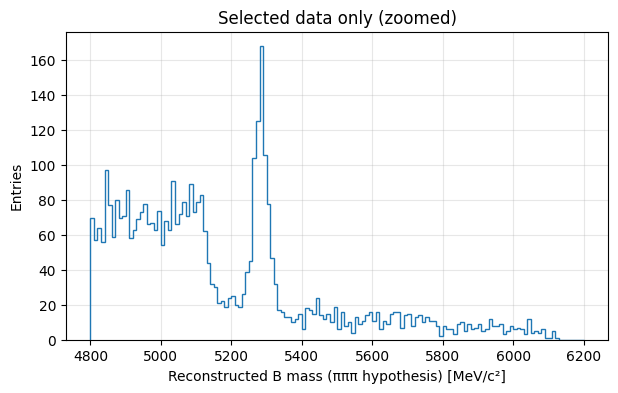

In [25]:
plt.figure(figsize=(7,4))
plt.hist(m_post, bins=140, histtype="step")
plt.xlabel("Reconstructed B mass (πππ hypothesis) [MeV/c²]")
plt.ylabel("Entries")
plt.title("Selected data only (post-cuts)")
plt.grid(alpha=0.3)
plt.show()

# Optional: zoom where the B peak should be
plt.figure(figsize=(7,4))
plt.hist(m_post, bins=140, range=(4800, 6200), histtype="step")
plt.xlabel("Reconstructed B mass (πππ hypothesis) [MeV/c²]")
plt.ylabel("Entries")
plt.title("Selected data only (zoomed)")
plt.grid(alpha=0.3)
plt.show()

#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [27]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!pip install lmfit

# checking out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)

In [ ]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.

# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

Entries pre-cuts: 5135823
Entries post-cuts: 12840
Kept fraction: 0.0025000861595113385


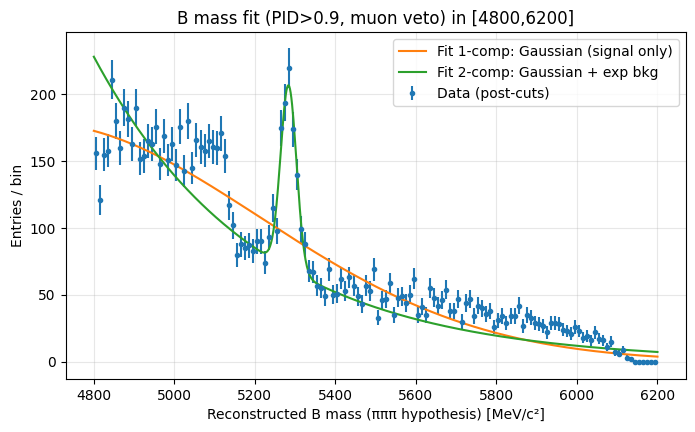


--- 1-component (Gaussian only) ---
Ns = 24867.8 ± 1492.8
mu = 4656.17 ± 37.20  MeV
sig= 555.22 ± 14.83  MeV

--- 2-component (Gaussian + exp background) ---
Ns = 677.4 ± 38.6
mu = 5283.70 ± 1.25  MeV
sig= 19.63 ± 1.19  MeV
Nb = 22.8 ± 0.3
k  = -0.00247 ± 0.00003  1/MeV

Approx yields in window [4800,6200]:  Signal ~ 677,  Background ~ 8966


In [28]:
from scipy.optimize import curve_fit

# ----------------------------
# 0) Choose our cut tightness
# ----------------------------
pid_thr = 0.9
selection = (
    f"(H1_ProbPi > {pid_thr}) & (H2_ProbPi > {pid_thr}) & (H3_ProbPi > {pid_thr}) & "
    f"(H1_isMuon == 0) & (H2_isMuon == 0) & (H3_isMuon == 0)"
)

# ---------------------------------------
# 1) Loading branches needed for B mass reco
# ---------------------------------------
vars_to_load = [
    "H1_PX","H1_PY","H1_PZ","H1_ProbPi","H1_isMuon",
    "H2_PX","H2_PY","H2_PZ","H2_ProbPi","H2_isMuon",
    "H3_PX","H3_PY","H3_PZ","H3_ProbPi","H3_isMuon",
]
arr_all = tree.arrays(vars_to_load)
arr_sel = tree.arrays(vars_to_load, cut=selection)

# ---------------------------------------
# 2) Reconstructing invariant mass (πππ hypo)
# ---------------------------------------
m_pi = 139.57039  # MeV/c^2

def reco_B_mass(arr):
    px1, py1, pz1 = ak.to_numpy(arr["H1_PX"]), ak.to_numpy(arr["H1_PY"]), ak.to_numpy(arr["H1_PZ"])
    px2, py2, pz2 = ak.to_numpy(arr["H2_PX"]), ak.to_numpy(arr["H2_PY"]), ak.to_numpy(arr["H2_PZ"])
    px3, py3, pz3 = ak.to_numpy(arr["H3_PX"]), ak.to_numpy(arr["H3_PY"]), ak.to_numpy(arr["H3_PZ"])

    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    p3 = np.sqrt(px3*px3 + py3*py3 + pz3*pz3)

    E1 = np.sqrt(p1*p1 + m_pi*m_pi)
    E2 = np.sqrt(p2*p2 + m_pi*m_pi)
    E3 = np.sqrt(p3*p3 + m_pi*m_pi)

    PX = px1 + px2 + px3
    PY = py1 + py2 + py3
    PZ = pz1 + pz2 + pz3
    E  = E1 + E2 + E3

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    m2 = np.maximum(m2, 0)  # numerical safety
    return np.sqrt(m2)

m_pre  = reco_B_mass(arr_all)
m_post = reco_B_mass(arr_sel)

print("Entries pre-cuts:", len(m_pre))
print("Entries post-cuts:", len(m_post))
print("Kept fraction:", len(m_post)/len(m_pre))

# ---------------------------------------
# 3) Histogram for fitting (post-cuts only)
# ---------------------------------------
fit_lo, fit_hi = 4800, 6200  # focus around the B region
bins = 140

counts, edges = np.histogram(m_post, bins=bins, range=(fit_lo, fit_hi))
centers = 0.5*(edges[:-1] + edges[1:])
width = edges[1] - edges[0]

# Poisson errors (avoiding zeros -> 1 for stability in chi2 fit)
sigma = np.sqrt(np.maximum(counts, 1))

# ---------------------------------------
# 4) Defineing models (counts-per-bin models)
# ---------------------------------------
def gauss_counts(x, N, mu, sig):
    # N is total signal yield in the fit range (approximately)
    return N * (1.0/(np.sqrt(2*np.pi)*sig)) * np.exp(-0.5*((x-mu)/sig)**2) * width

def gauss_plus_exp_counts(x, Ns, mu, sig, Nb, k):
    # background ~ exp(k*(x-fit_lo)) normalized-ish by Nb scale in counts
    # (k < 0 gives falling background)
    sig_part = gauss_counts(x, Ns, mu, sig)
    bkg_part = Nb * np.exp(k*(x - fit_lo)) * width
    return sig_part + bkg_part

# ---------------------------------------
# 5) Initial guesses
# ---------------------------------------
# crude peak guess from histogram maximum
peak_x = centers[np.argmax(counts)] if np.any(counts) else 5280.0
Ns0 = max(counts.sum()*0.5, 10)     # half events as "signal" starting guess
mu0 = peak_x
sig0 = 20.0                         # MeV-ish start
Nb0 = max(counts.sum()*0.5, 10)     # other half as "bkg"
k0  = -0.001                        # gentle falling

# ---------------------------------------
# 6) Fit 1-component (signal only)
# ---------------------------------------
popt1, pcov1 = curve_fit(
    gauss_counts, centers, counts,
    p0=[Ns0, mu0, sig0],
    sigma=sigma, absolute_sigma=True,
    maxfev=20000
)

# ---------------------------------------
# 7) Fit 2-component (signal + background)
# ---------------------------------------
popt2, pcov2 = curve_fit(
    gauss_plus_exp_counts, centers, counts,
    p0=[Ns0, mu0, sig0, Nb0, k0],
    sigma=sigma, absolute_sigma=True,
    maxfev=40000
)

# ---------------------------------------
# 8) Plot: post-cuts hist + both fits
# ---------------------------------------
xplot = np.linspace(fit_lo, fit_hi, 800)

plt.figure(figsize=(8,4.5))
plt.errorbar(centers, counts, yerr=sigma, fmt=".", label="Data (post-cuts)")

plt.plot(xplot, gauss_counts(xplot, *popt1), label="Fit 1-comp: Gaussian (signal only)")
plt.plot(xplot, gauss_plus_exp_counts(xplot, *popt2), label="Fit 2-comp: Gaussian + exp bkg")

plt.xlabel("Reconstructed B mass (πππ hypothesis) [MeV/c²]")
plt.ylabel("Entries / bin")
plt.title(f"B mass fit (PID>{pid_thr}, muon veto) in [{fit_lo},{fit_hi}]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ---------------------------------------
# 9) Print results (with 1σ uncertainties)
# ---------------------------------------
def errs(pcov):
    return np.sqrt(np.diag(pcov))

e1 = errs(pcov1)
e2 = errs(pcov2)

print("\n--- 1-component (Gaussian only) ---")
print(f"Ns = {popt1[0]:.1f} ± {e1[0]:.1f}")
print(f"mu = {popt1[1]:.2f} ± {e1[1]:.2f}  MeV")
print(f"sig= {popt1[2]:.2f} ± {e1[2]:.2f}  MeV")

print("\n--- 2-component (Gaussian + exp background) ---")
print(f"Ns = {popt2[0]:.1f} ± {e2[0]:.1f}")
print(f"mu = {popt2[1]:.2f} ± {e2[1]:.2f}  MeV")
print(f"sig= {popt2[2]:.2f} ± {e2[2]:.2f}  MeV")
print(f"Nb = {popt2[3]:.1f} ± {e2[3]:.1f}")
print(f"k  = {popt2[4]:.5f} ± {e2[4]:.5f}  1/MeV")

# Approx yields in fit window:
Ns_fit = popt2[0]
Nb_fit = np.sum((popt2[3] * np.exp(popt2[4]*(centers - fit_lo)) * width))
print(f"\nApprox yields in window [{fit_lo},{fit_hi}]:  Signal ~ {Ns_fit:.0f},  Background ~ {Nb_fit:.0f}")


Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [ ]:
#find the area under your curve(s)! maybe make a pretty little table...

In [30]:
from math import erf, sqrt, exp
import numpy as np
import pandas as pd



# ==============================
# Fiting parameters (from our 2-comp fit)
# ==============================
Ns    = 677.4      # signal yield parameter in our model
mu    = 5283.70    # MeV
sigma = 19.63      # MeV

Nb = 22.8          # background density scale in our model
k  = -0.00247      # 1/MeV

# ==============================
# Fiting window
# ==============================
fit_lo, fit_hi = 4800, 6200

# ==============================
# Signal: Gaussian fraction in [fit_lo, fit_hi]
# (Gaussian is normalized; multiplying by Ns gives signal yield in the window)
# ==============================
def gaussian_fraction(a, b, mu, sig):
    return 0.5 * (
        erf((b - mu) / (sqrt(2) * sig)) -
        erf((a - mu) / (sqrt(2) * sig))
    )

S = Ns * gaussian_fraction(fit_lo, fit_hi, mu, sigma)

# ==============================
# Background: MUST match our fitted background form:
# bkg_density(m) = Nb * exp(k*(m - fit_lo))     [counts/MeV]
# yield B = ∫_{fit_lo}^{fit_hi} bkg_density(m) dm
# ==============================
def background_yield(a, b, Nb, k, fit_lo):
    if abs(k) < 1e-12:
        return Nb * (b - a)  # flat limit if k ~ 0
    return Nb * (exp(k * (b - fit_lo)) - exp(k * (a - fit_lo))) / k

B = background_yield(fit_lo, fit_hi, Nb, k, fit_lo)

# ==============================
# Metrics
# ==============================
Z = S / np.sqrt(S + B) if (S + B) > 0 else np.nan
purity = S / (S + B) if (S + B) > 0 else np.nan
s_over_b = S / B if B > 0 else np.inf

# ==============================
# Output table
# ==============================
df = pd.DataFrame({
    "Component": ["Signal", "Background"],
    f"Yield [{fit_lo}–{fit_hi}]": [S, B]
})

print(df.to_string(index=False))
print("\nMetrics:")
print(f"Significance Z = {Z:.2f}")
print(f"S/B = {s_over_b:.4f}")
print(f"Purity = {purity:.4f}")


 Component  Yield [4800–6200]
    Signal         677.400000
Background        8940.067528

Metrics:
Significance Z = 6.91
S/B = 0.0758
Purity = 0.0704


#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

In [ ]:
#Here do your calculation of the final result

Post-preselection events: 1632
B+ candidates: 868
B- candidates: 764


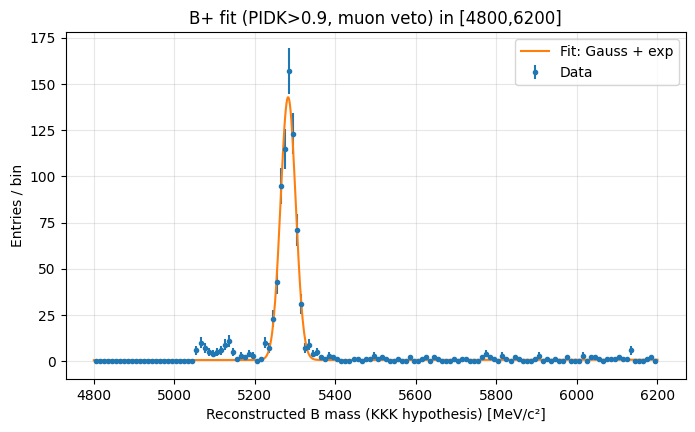

B+ fit (PIDK>0.9, muon veto) in [4800,6200]
Ns = 665.6 ± 26.0
mu = 5282.59 ± 0.74 MeV
sig= 18.66 ± 0.57 MeV
Nb = 0.0518 ± 0.018
k  = 0.00029 ± 0.00037 1/MeV



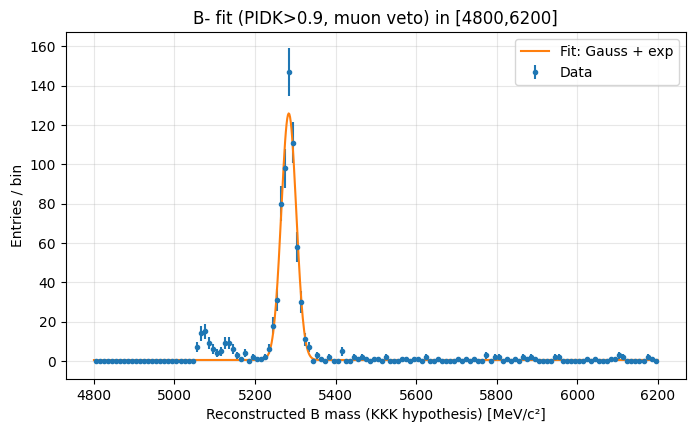

B- fit (PIDK>0.9, muon veto) in [4800,6200]
Ns = 581.0 ± 24.3
mu = 5283.89 ± 0.78 MeV
sig= 18.49 ± 0.62 MeV
Nb = 0.048 ± 0.0189
k  = 0.00009 ± 0.00045 1/MeV

Final results
NB+ = 665.6 (fit)
NB- = 581.0 (fit)
A   = -0.06791
sA  = 0.02826


In [31]:
# ----------------------------
# Settings
# ----------------------------
pid_thr = 0.9
fit_lo, fit_hi = 4800, 6200
bins = 140
m_K = 493.677  # MeV/c^2 (Kaon mass)

# ----------------------------
# Loading needed branches
# ----------------------------
vars_to_load = [
    "H1_PX","H1_PY","H1_PZ","H1_ProbK","H1_isMuon","H1_Charge",
    "H2_PX","H2_PY","H2_PZ","H2_ProbK","H2_isMuon","H2_Charge",
    "H3_PX","H3_PY","H3_PZ","H3_ProbK","H3_isMuon","H3_Charge",
]
arr = tree.arrays(vars_to_load)

# ----------------------------
# Preselection: Kaon PID + muon veto
# ----------------------------
preselect = (
    (arr["H1_ProbK"] > pid_thr) & (arr["H2_ProbK"] > pid_thr) & (arr["H3_ProbK"] > pid_thr) &
    (arr["H1_isMuon"] == 0) & (arr["H2_isMuon"] == 0) & (arr["H3_isMuon"] == 0)
)

arr = arr[preselect]

# ----------------------------
# Spliting into B+ (K+K+K-) and B- (K-K-K+)
# Using charges: +1 / -1
# Rule: sum of charges = +1 => B+ ; sum = -1 => B-
# Throwing away sum = +3, -3, 0
# ----------------------------
qsum = arr["H1_Charge"] + arr["H2_Charge"] + arr["H3_Charge"]
is_Bplus  = (qsum == +1)
is_Bminus = (qsum == -1)

arr_Bp = arr[is_Bplus]
arr_Bm = arr[is_Bminus]

print("Post-preselection events:", len(arr))
print("B+ candidates:", len(arr_Bp))
print("B- candidates:", len(arr_Bm))

# ----------------------------
# Reconstructing invariant mass with K,K,K hypothesis
# ----------------------------
def reco_B_mass_KKK(a):
    px1, py1, pz1 = ak.to_numpy(a["H1_PX"]), ak.to_numpy(a["H1_PY"]), ak.to_numpy(a["H1_PZ"])
    px2, py2, pz2 = ak.to_numpy(a["H2_PX"]), ak.to_numpy(a["H2_PY"]), ak.to_numpy(a["H2_PZ"])
    px3, py3, pz3 = ak.to_numpy(a["H3_PX"]), ak.to_numpy(a["H3_PY"]), ak.to_numpy(a["H3_PZ"])

    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    p3 = np.sqrt(px3*px3 + py3*py3 + pz3*pz3)

    E1 = np.sqrt(p1*p1 + m_K*m_K)
    E2 = np.sqrt(p2*p2 + m_K*m_K)
    E3 = np.sqrt(p3*p3 + m_K*m_K)

    PX = px1 + px2 + px3
    PY = py1 + py2 + py3
    PZ = pz1 + pz2 + pz3
    E  = E1 + E2 + E3

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    m2 = np.maximum(m2, 0)
    return np.sqrt(m2)

mBp = reco_B_mass_KKK(arr_Bp)
mBm = reco_B_mass_KKK(arr_Bm)

# ----------------------------
# Fit model (counts per bin) = Gaussian + exp background
# IMPORTANT: background is defined exactly like in our previous code
# ----------------------------
def fit_yield(masses, title=""):
    counts, edges = np.histogram(masses, bins=bins, range=(fit_lo, fit_hi))
    centers = 0.5*(edges[:-1] + edges[1:])
    width = edges[1] - edges[0]
    sigma_y = np.sqrt(np.maximum(counts, 1))

    def gauss_counts(x, N, mu, sig):
        return N * (1.0/(np.sqrt(2*np.pi)*sig)) * np.exp(-0.5*((x-mu)/sig)**2) * width

    def gauss_plus_exp_counts(x, Ns, mu, sig, Nb, k):
        sig_part = gauss_counts(x, Ns, mu, sig)
        bkg_part = Nb * np.exp(k*(x - fit_lo)) * width
        return sig_part + bkg_part

    # initial guesses
    peak_x = centers[np.argmax(counts)] if np.any(counts) else 5280.0
    Ns0 = max(counts.sum()*0.1, 10)
    mu0 = peak_x
    sig0 = 20.0
    Nb0 = max(counts.sum()*0.9/(fit_hi-fit_lo), 1)  # background density-ish guess
    k0  = -0.001

    popt, pcov = curve_fit(
        gauss_plus_exp_counts, centers, counts,
        p0=[Ns0, mu0, sig0, Nb0, k0],
        sigma=sigma_y, absolute_sigma=True,
        maxfev=40000
    )
    perr = np.sqrt(np.diag(pcov))

    # Plot
    xplot = np.linspace(fit_lo, fit_hi, 800)
    plt.figure(figsize=(8,4.5))
    plt.errorbar(centers, counts, yerr=sigma_y, fmt=".", label="Data")
    plt.plot(xplot, gauss_plus_exp_counts(xplot, *popt), label="Fit: Gauss + exp")
    plt.xlabel("Reconstructed B mass (KKK hypothesis) [MeV/c²]")
    plt.ylabel("Entries / bin")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    Ns_fit, mu_fit, sig_fit, Nb_fit, k_fit = popt
    eNs = perr[0]

    print(title)
    print(f"Ns = {Ns_fit:.1f} ± {eNs:.1f}")
    print(f"mu = {mu_fit:.2f} ± {perr[1]:.2f} MeV")
    print(f"sig= {sig_fit:.2f} ± {perr[2]:.2f} MeV")
    print(f"Nb = {Nb_fit:.3g} ± {perr[3]:.3g}")
    print(f"k  = {k_fit:.5f} ± {perr[4]:.5f} 1/MeV\n")

    return Ns_fit, eNs

# ----------------------------
# Fiting B+ and B- subsets
# ----------------------------
NBp, eNBp = fit_yield(mBp, title=f"B+ fit (PIDK>{pid_thr}, muon veto) in [{fit_lo},{fit_hi}]")
NBm, eNBm = fit_yield(mBm, title=f"B- fit (PIDK>{pid_thr}, muon veto) in [{fit_lo},{fit_hi}]")

# ----------------------------
# Asymmetry and uncertainty
# A = (NB- - NB+) / (NB- + NB+)
# sigma_A = sqrt((1 - A^2) / (NB- + NB+))
# (as given in task; uses only total counts, not fit uncertainties)
# ----------------------------
A = (NBm - NBp) / (NBm + NBp)
sigma_A = np.sqrt((1 - A*A) / (NBm + NBp))

print("Final results")
print(f"NB+ = {NBp:.1f} (fit)")
print(f"NB- = {NBm:.1f} (fit)")
print(f"A   = {A:.5f}")
print(f"sA  = {sigma_A:.5f}")


In [ ]:
# Results look good: We have peaks for both B_{+} and B_{-} at the right places
# But assymetry is small and doesn't explain excess of matter in the universe


#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [ ]:
#Define a function to find the invarient mass of two given Kaons

In [32]:

import numpy as np
import awkward as ak

mK = 493.677  # MeV/c^2

def inv_mass_two_kaons(arr, a, b, m=mK):
    """
    Invariant mass of two tracks a and b in `arr` under kaon mass hypothesis.

    a, b: strings like "H1", "H2", "H3"
    returns: numpy array of masses in MeV
    """
    px1 = ak.to_numpy(arr[f"{a}_PX"]); py1 = ak.to_numpy(arr[f"{a}_PY"]); pz1 = ak.to_numpy(arr[f"{a}_PZ"])
    px2 = ak.to_numpy(arr[f"{b}_PX"]); py2 = ak.to_numpy(arr[f"{b}_PY"]); pz2 = ak.to_numpy(arr[f"{b}_PZ"])

    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)

    E1 = np.sqrt(p1*p1 + m*m)
    E2 = np.sqrt(p2*p2 + m*m)

    PX = px1 + px2
    PY = py1 + py2
    PZ = pz1 + pz2
    E  = E1 + E2

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    m2 = np.maximum(m2, 0)
    return np.sqrt(m2)


In [33]:
m12 = inv_mass_two_kaons(arr_sel, "H1", "H2")
m13 = inv_mass_two_kaons(arr_sel, "H1", "H3")
m23 = inv_mass_two_kaons(arr_sel, "H2", "H3")

m12_sq = m12**2
m13_sq = m13**2
m23_sq = m23**2

In [ ]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

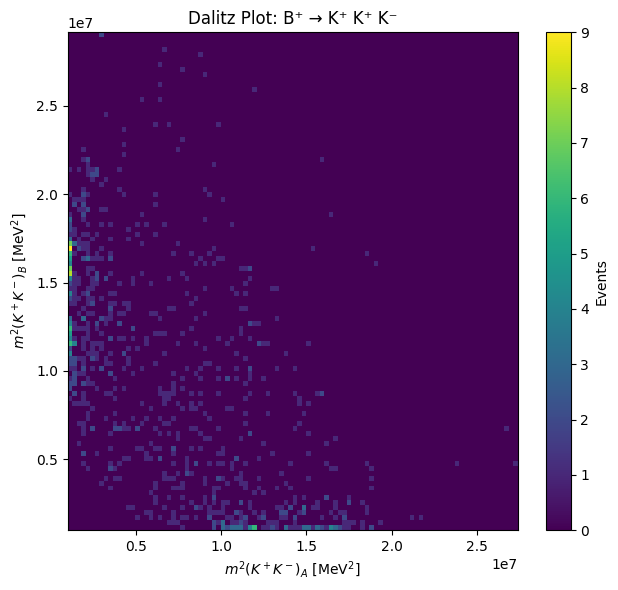

In [34]:
mK = 493.677  # MeV/c^2

def inv_mass(px1, py1, pz1, px2, py2, pz2, m=mK):
    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    E1 = np.sqrt(p1*p1 + m*m)
    E2 = np.sqrt(p2*p2 + m*m)

    PX = px1 + px2
    PY = py1 + py2
    PZ = pz1 + pz2
    E  = E1 + E2

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    m2 = np.maximum(m2, 0)
    return np.sqrt(m2)

# ----------------------------
# Extracting numpy arrays (B+ only)
# ----------------------------
q1 = ak.to_numpy(arr_Bp["H1_Charge"])
q2 = ak.to_numpy(arr_Bp["H2_Charge"])
q3 = ak.to_numpy(arr_Bp["H3_Charge"])

px1, py1, pz1 = map(ak.to_numpy, (arr_Bp["H1_PX"], arr_Bp["H1_PY"], arr_Bp["H1_PZ"]))
px2, py2, pz2 = map(ak.to_numpy, (arr_Bp["H2_PX"], arr_Bp["H2_PY"], arr_Bp["H2_PZ"]))
px3, py3, pz3 = map(ak.to_numpy, (arr_Bp["H3_PX"], arr_Bp["H3_PY"], arr_Bp["H3_PZ"]))

# ----------------------------
# Identifying K− in each event
# ----------------------------
neg1 = (q1 == -1)
neg2 = (q2 == -1)
neg3 = (q3 == -1)

mA = np.empty(len(q1))
mB = np.empty(len(q1))

# Case: H1 is K− → pairs (H2,H1) & (H3,H1)
idx = neg1
mA[idx] = inv_mass(px2[idx], py2[idx], pz2[idx], px1[idx], py1[idx], pz1[idx])
mB[idx] = inv_mass(px3[idx], py3[idx], pz3[idx], px1[idx], py1[idx], pz1[idx])

# Case: H2 is K− → pairs (H1,H2) & (H3,H2)
idx = neg2
mA[idx] = inv_mass(px1[idx], py1[idx], pz1[idx], px2[idx], py2[idx], pz2[idx])
mB[idx] = inv_mass(px3[idx], py3[idx], pz3[idx], px2[idx], py2[idx], pz2[idx])

# Case: H3 is K− → pairs (H1,H3) & (H2,H3)
idx = neg3
mA[idx] = inv_mass(px1[idx], py1[idx], pz1[idx], px3[idx], py3[idx], pz3[idx])
mB[idx] = inv_mass(px2[idx], py2[idx], pz2[idx], px3[idx], py3[idx], pz3[idx])

# ----------------------------
# Dalitz variables (m²)
# ----------------------------
x = mA**2
y = mB**2

# ----------------------------
# Plot Dalitz
# ----------------------------
plt.figure(figsize=(6.5,6))
plt.hist2d(x, y, bins=100)
plt.xlabel(r"$m^2(K^+K^-)_A$ [MeV$^2$]")
plt.ylabel(r"$m^2(K^+K^-)_B$ [MeV$^2$]")
plt.title("Dalitz Plot: B⁺ → K⁺ K⁺ K⁻")
plt.colorbar(label="Events")
plt.tight_layout()
plt.show()


We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [ ]:
#Make the revised Dalitz plot here for B+ mesons

B+ events in signal window: 685


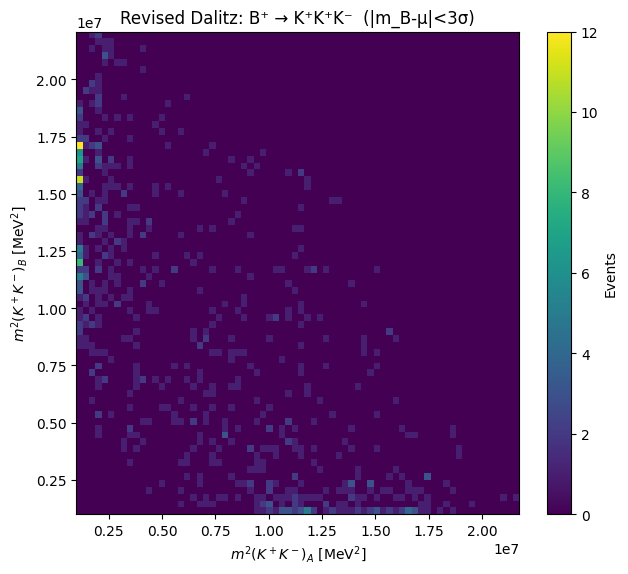

In [35]:
mK = 493.677  # MeV/c^2

def inv_mass(px1, py1, pz1, px2, py2, pz2, m=mK):
    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    E1 = np.sqrt(p1*p1 + m*m)
    E2 = np.sqrt(p2*p2 + m*m)
    PX, PY, PZ = px1+px2, py1+py2, pz1+pz2
    E = E1 + E2
    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    return np.sqrt(np.maximum(m2, 0))

def reco_B_mass_KKK(arr):
    px1, py1, pz1 = map(ak.to_numpy, (arr["H1_PX"], arr["H1_PY"], arr["H1_PZ"]))
    px2, py2, pz2 = map(ak.to_numpy, (arr["H2_PX"], arr["H2_PY"], arr["H2_PZ"]))
    px3, py3, pz3 = map(ak.to_numpy, (arr["H3_PX"], arr["H3_PY"], arr["H3_PZ"]))

    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    p3 = np.sqrt(px3*px3 + py3*py3 + pz3*pz3)

    E1 = np.sqrt(p1*p1 + mK*mK)
    E2 = np.sqrt(p2*p2 + mK*mK)
    E3 = np.sqrt(p3*p3 + mK*mK)

    PX, PY, PZ = px1+px2+px3, py1+py2+py3, pz1+pz2+pz3
    E = E1 + E2 + E3

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    return np.sqrt(np.maximum(m2, 0))

# ----------------------------
# 1) Applying B-mass signal window to B+ sample (REVISED part)
# Use your B+ fit results:
mu_Bp  = 5282.59
sig_Bp = 18.66
n_sigma = 3
# ----------------------------
mB = reco_B_mass_KKK(arr_Bp)
arr_Bp_sig = arr_Bp[(mB > mu_Bp - n_sigma*sig_Bp) & (mB < mu_Bp + n_sigma*sig_Bp)]
print("B+ events in signal window:", len(arr_Bp_sig))

# ----------------------------
# 2) Building the two K+K- masses (B+ has exactly one K-)
# ----------------------------
q1 = ak.to_numpy(arr_Bp_sig["H1_Charge"])
q2 = ak.to_numpy(arr_Bp_sig["H2_Charge"])
q3 = ak.to_numpy(arr_Bp_sig["H3_Charge"])

px1, py1, pz1 = map(ak.to_numpy, (arr_Bp_sig["H1_PX"], arr_Bp_sig["H1_PY"], arr_Bp_sig["H1_PZ"]))
px2, py2, pz2 = map(ak.to_numpy, (arr_Bp_sig["H2_PX"], arr_Bp_sig["H2_PY"], arr_Bp_sig["H2_PZ"]))
px3, py3, pz3 = map(ak.to_numpy, (arr_Bp_sig["H3_PX"], arr_Bp_sig["H3_PY"], arr_Bp_sig["H3_PZ"]))

neg1, neg2, neg3 = (q1 == -1), (q2 == -1), (q3 == -1)

mA = np.empty(len(q1))
mB = np.empty(len(q1))

idx = neg1
mA[idx] = inv_mass(px2[idx], py2[idx], pz2[idx], px1[idx], py1[idx], pz1[idx])
mB[idx] = inv_mass(px3[idx], py3[idx], pz3[idx], px1[idx], py1[idx], pz1[idx])

idx = neg2
mA[idx] = inv_mass(px1[idx], py1[idx], pz1[idx], px2[idx], py2[idx], pz2[idx])
mB[idx] = inv_mass(px3[idx], py3[idx], pz3[idx], px2[idx], py2[idx], pz2[idx])

idx = neg3
mA[idx] = inv_mass(px1[idx], py1[idx], pz1[idx], px3[idx], py3[idx], pz3[idx])
mB[idx] = inv_mass(px2[idx], py2[idx], pz2[idx], px3[idx], py3[idx], pz3[idx])

x = mA**2
y = mB**2

# ----------------------------
# 3) Plot (choosing  binning)
# ----------------------------
plt.figure(figsize=(6.5,6))
plt.hist2d(x, y, bins=70)  # 60–100 is fine; 70 works well at your stats
plt.xlabel(r"$m^2(K^+K^-)_A$ [MeV$^2$]")
plt.ylabel(r"$m^2(K^+K^-)_B$ [MeV$^2$]")
plt.title(f"Revised Dalitz: B⁺ → K⁺K⁺K⁻  (|m_B-μ|<{n_sigma}σ)")
plt.colorbar(label="Events")
plt.tight_layout()
plt.show()


In [ ]:
#Make the revised Dalitz plot here for B- mesons

B- events in signal window: 597


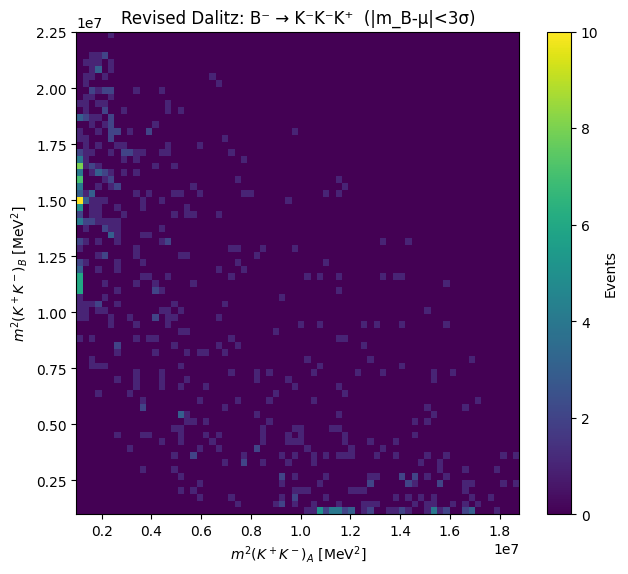

In [36]:
mK = 493.677  # MeV/c^2

def inv_mass(px1, py1, pz1, px2, py2, pz2, m=mK):
    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    E1 = np.sqrt(p1*p1 + m*m)
    E2 = np.sqrt(p2*p2 + m*m)
    PX, PY, PZ = px1+px2, py1+py2, pz1+pz2
    E = E1 + E2
    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    return np.sqrt(np.maximum(m2, 0))

def reco_B_mass_KKK(arr):
    px1, py1, pz1 = map(ak.to_numpy, (arr["H1_PX"], arr["H1_PY"], arr["H1_PZ"]))
    px2, py2, pz2 = map(ak.to_numpy, (arr["H2_PX"], arr["H2_PY"], arr["H2_PZ"]))
    px3, py3, pz3 = map(ak.to_numpy, (arr["H3_PX"], arr["H3_PY"], arr["H3_PZ"]))

    p1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1)
    p2 = np.sqrt(px2*px2 + py2*py2 + pz2*pz2)
    p3 = np.sqrt(px3*px3 + py3*py3 + pz3*pz3)

    E1 = np.sqrt(p1*p1 + mK*mK)
    E2 = np.sqrt(p2*p2 + mK*mK)
    E3 = np.sqrt(p3*p3 + mK*mK)

    PX, PY, PZ = px1+px2+px3, py1+py2+py3, pz1+pz2+pz3
    E = E1 + E2 + E3

    m2 = E*E - (PX*PX + PY*PY + PZ*PZ)
    return np.sqrt(np.maximum(m2, 0))

# ----------------------------
# 1) Applying B-mass signal window to B- sample
# Using our B- fit results:
mu_Bm  = 5283.89
sig_Bm = 18.49
n_sigma = 3
# ----------------------------
mB = reco_B_mass_KKK(arr_Bm)
arr_Bm_sig = arr_Bm[(mB > mu_Bm - n_sigma*sig_Bm) & (mB < mu_Bm + n_sigma*sig_Bm)]
print("B- events in signal window:", len(arr_Bm_sig))

# ----------------------------
# 2) Building the two K+K- masses (B- has exactly one K+)
# ----------------------------
q1 = ak.to_numpy(arr_Bm_sig["H1_Charge"])
q2 = ak.to_numpy(arr_Bm_sig["H2_Charge"])
q3 = ak.to_numpy(arr_Bm_sig["H3_Charge"])

px1, py1, pz1 = map(ak.to_numpy, (arr_Bm_sig["H1_PX"], arr_Bm_sig["H1_PY"], arr_Bm_sig["H1_PZ"]))
px2, py2, pz2 = map(ak.to_numpy, (arr_Bm_sig["H2_PX"], arr_Bm_sig["H2_PY"], arr_Bm_sig["H2_PZ"]))
px3, py3, pz3 = map(ak.to_numpy, (arr_Bm_sig["H3_PX"], arr_Bm_sig["H3_PY"], arr_Bm_sig["H3_PZ"]))

pos1, pos2, pos3 = (q1 == +1), (q2 == +1), (q3 == +1)

mA = np.empty(len(q1))
mB = np.empty(len(q1))

# Case: H1 is K+ → pairs (H1,H2) and (H1,H3)
idx = pos1
mA[idx] = inv_mass(px1[idx], py1[idx], pz1[idx], px2[idx], py2[idx], pz2[idx])
mB[idx] = inv_mass(px1[idx], py1[idx], pz1[idx], px3[idx], py3[idx], pz3[idx])

# Case: H2 is K+ → pairs (H2,H1) and (H2,H3)
idx = pos2
mA[idx] = inv_mass(px2[idx], py2[idx], pz2[idx], px1[idx], py1[idx], pz1[idx])
mB[idx] = inv_mass(px2[idx], py2[idx], pz2[idx], px3[idx], py3[idx], pz3[idx])

# Case: H3 is K+ → pairs (H3,H1) and (H3,H2)
idx = pos3
mA[idx] = inv_mass(px3[idx], py3[idx], pz3[idx], px1[idx], py1[idx], pz1[idx])
mB[idx] = inv_mass(px3[idx], py3[idx], pz3[idx], px2[idx], py2[idx], pz2[idx])

x = mA**2
y = mB**2

# ----------------------------
# 3) Plot
# ----------------------------
plt.figure(figsize=(6.5,6))
plt.hist2d(x, y, bins=70)
plt.xlabel(r"$m^2(K^+K^-)_A$ [MeV$^2$]")
plt.ylabel(r"$m^2(K^+K^-)_B$ [MeV$^2$]")
plt.title(f"Revised Dalitz: B⁻ → K⁻K⁻K⁺  (|m_B-μ|<{n_sigma}σ)")
plt.colorbar(label="Events")
plt.tight_layout()
plt.show()


In [ ]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)